# MobileNet
https://keras.io/api/applications/mobilenet/

MobileNet is a streamlined architecture that uses depthwise separable convolutions to construct lightweight deep convolutional neural networks and provides an efficient model for mobile and embedded vision application.

To see ImageNet classes list:

https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/

In [ ]:
import keras.applications

import numpy as np

In [ ]:
MNv2 = keras.applications.MobileNetV2(weights='imagenet')

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
MNv3Small = keras.applications.MobileNetV3Small(weights='imagenet')

/usr/local/lib/python3.11/dist-packages/keras/src/applications/mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


10734624/10734624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
MNv3Large = keras.applications.MobileNetV3Large(weights='imagenet')

/usr/local/lib/python3.11/dist-packages/keras/src/applications/mobilenet_v3.py:517: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


22661472/22661472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

## First image -> mobile

<IPython.core.display.Javascript object>

Saved to photo.jpg


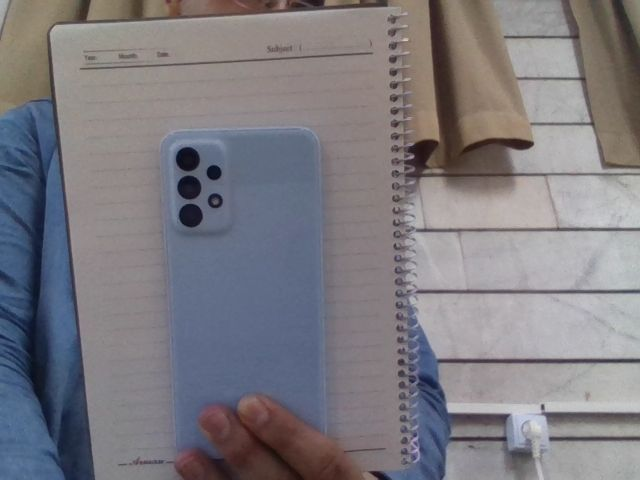

In [ ]:
from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

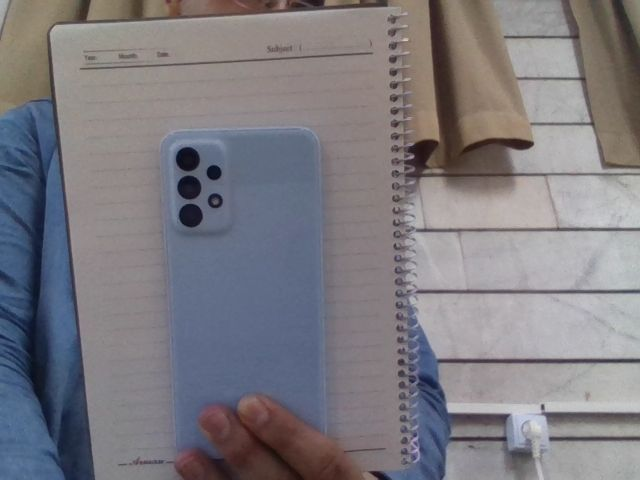

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
img = cv2.imread('photo.jpg', cv2.IMREAD_UNCHANGED)
cv2_imshow(img)

In [ ]:
img = cv2.resize(img, (224, 224))
img = np.expand_dims(img, axis=0)

In [ ]:
v2_img = keras.applications.mobilenet_v2.preprocess_input(img)
pred = MNv2.predict(v2_img)
keras.applications.mobilenet_v2.decode_predictions(pred, top=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


[[('n04141975', 'scale', 0.055103578),
  ('n03584254', 'iPod', 0.04947479),
  ('n03041632', 'cleaver', 0.045570426),
  ('n02992529', 'cellular_telephone', 0.030240968),
  ('n04118776', 'rule', 0.02402168)]]

In [ ]:
v3_small_img = keras.applications.mobilenet_v3.preprocess_input(img)
pred = MNv3Small.predict(v3_small_img)
keras.applications.mobilenet_v3.decode_predictions(pred, top=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


[[('n04118776', 'rule', 0.15143517),
  ('n02971356', 'carton', 0.04386914),
  ('n03127925', 'crate', 0.032992616),
  ('n04235860', 'sleeping_bag', 0.024315422),
  ('n02104029', 'kuvasz', 0.022259241)]]

In [ ]:
v3_large_img = keras.applications.mobilenet_v3.preprocess_input(img)
pred = MNv3Large.predict(v3_large_img)
keras.applications.mobilenet_v3.decode_predictions(pred, top=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


[[('n04125021', 'safe', 0.09292494),
  ('n04074963', 'remote_control', 0.06290234),
  ('n03187595', 'dial_telephone', 0.06285518),
  ('n02971356', 'carton', 0.04792617),
  ('n03467068', 'guillotine', 0.03740945)]]

## Second image -> cup

<IPython.core.display.Javascript object>

Saved to photo.jpg


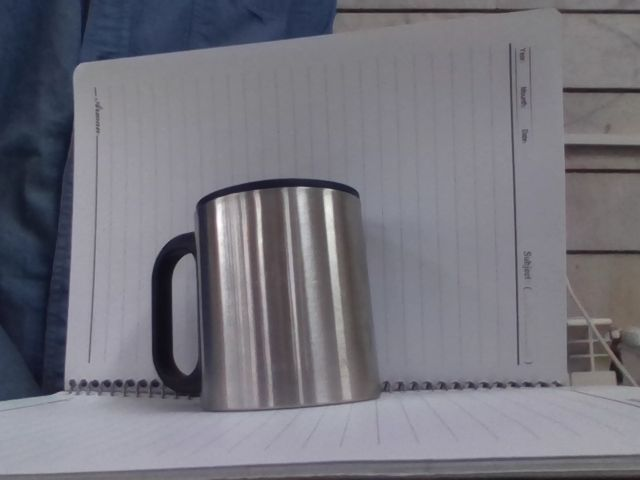

In [ ]:
from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

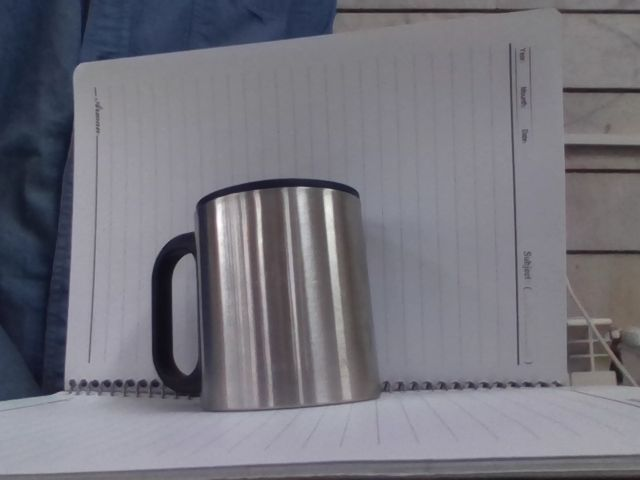

In [ ]:
img = cv2.imread('photo.jpg', cv2.IMREAD_UNCHANGED)
cv2_imshow(img)

In [ ]:
img = cv2.resize(img, (224, 224))
img = np.expand_dims(img, axis=0)

In [ ]:
v2_img = keras.applications.mobilenet_v2.preprocess_input(img)
pred = MNv2.predict(v2_img)
keras.applications.mobilenet_v2.decode_predictions(pred, top=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


[[('n07930864', 'cup', 0.21070775),
  ('n03950228', 'pitcher', 0.13834897),
  ('n03063689', 'coffeepot', 0.12820318),
  ('n03063599', 'coffee_mug', 0.103292055),
  ('n04560804', 'water_jug', 0.06606047)]]

In [ ]:
v3_small_img = keras.applications.mobilenet_v3.preprocess_input(img)
pred = MNv3Small.predict(v3_small_img)
keras.applications.mobilenet_v3.decode_predictions(pred, top=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


[[('n04442312', 'toaster', 0.21846603),
  ('n03063689', 'coffeepot', 0.14347212),
  ('n04560804', 'water_jug', 0.03435043),
  ('n03297495', 'espresso_maker', 0.030482315),
  ('n03961711', 'plate_rack', 0.022459386)]]

In [ ]:
v3_large_img = keras.applications.mobilenet_v3.preprocess_input(img)
pred = MNv3Large.predict(v3_large_img)
keras.applications.mobilenet_v3.decode_predictions(pred, top=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


[[('n03063689', 'coffeepot', 0.24271011),
  ('n04560804', 'water_jug', 0.12710613),
  ('n03297495', 'espresso_maker', 0.120091565),
  ('n04070727', 'refrigerator', 0.06727573),
  ('n03924679', 'photocopier', 0.049114738)]]

## third image -> glasses

<IPython.core.display.Javascript object>

Saved to photo.jpg


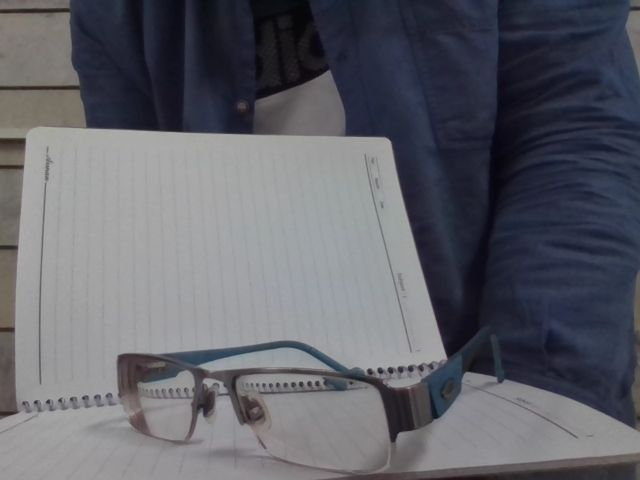

In [ ]:
from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

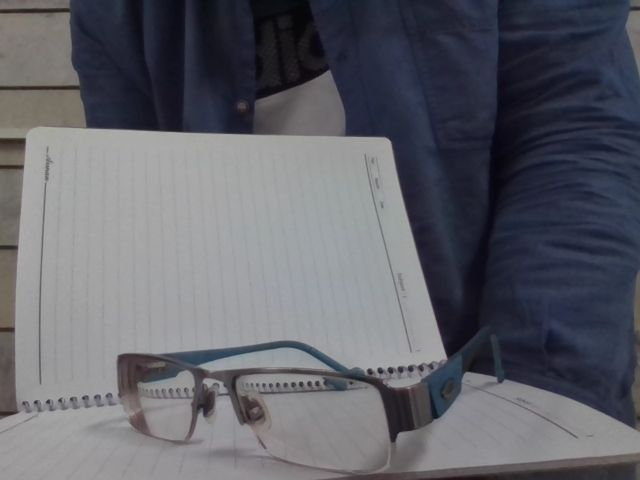

In [ ]:
img = cv2.imread('photo.jpg', cv2.IMREAD_UNCHANGED)
cv2_imshow(img)

In [ ]:
img = cv2.resize(img, (224, 224))
img = np.expand_dims(img, axis=0)

In [ ]:
v2_img = keras.applications.mobilenet_v2.preprocess_input(img)
pred = MNv2.predict(v2_img)
keras.applications.mobilenet_v2.decode_predictions(pred, top=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


[[('n02971356', 'carton', 0.07859467),
  ('n02840245', 'binder', 0.05121425),
  ('n03832673', 'notebook', 0.03892613),
  ('n03291819', 'envelope', 0.038121406),
  ('n04004767', 'printer', 0.03382359)]]

In [ ]:
v3_small_img = keras.applications.mobilenet_v3.preprocess_input(img)
pred = MNv3Small.predict(v3_small_img)
keras.applications.mobilenet_v3.decode_predictions(pred, top=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


[[('n03832673', 'notebook', 0.039175898),
  ('n03388183', 'fountain_pen', 0.03914016),
  ('n02883205', 'bow_tie', 0.037954763),
  ('n04033901', 'quill', 0.034037925),
  ('n03584829', 'iron', 0.029792283)]]

In [ ]:
v3_large_img = keras.applications.mobilenet_v3.preprocess_input(img)
pred = MNv3Large.predict(v3_large_img)
keras.applications.mobilenet_v3.decode_predictions(pred, top=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


[[('n02840245', 'binder', 0.61001116),
  ('n03709823', 'mailbag', 0.029808735),
  ('n03179701', 'desk', 0.021621637),
  ('n02787622', 'banjo', 0.012413426),
  ('n04026417', 'purse', 0.010268983)]]

## Fourth image -> comb

<IPython.core.display.Javascript object>

Saved to photo.jpg


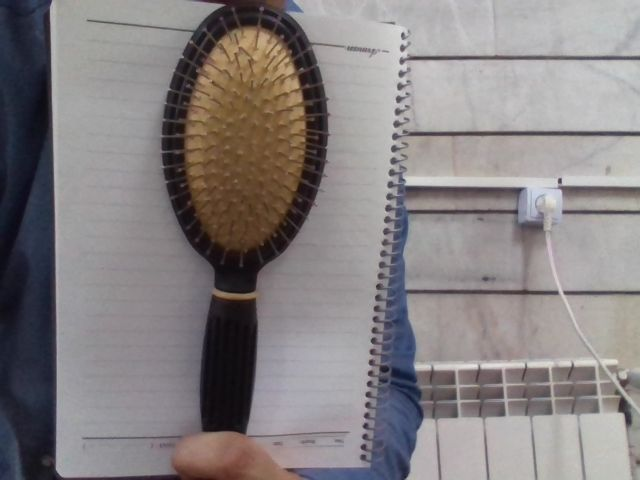

In [ ]:
from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

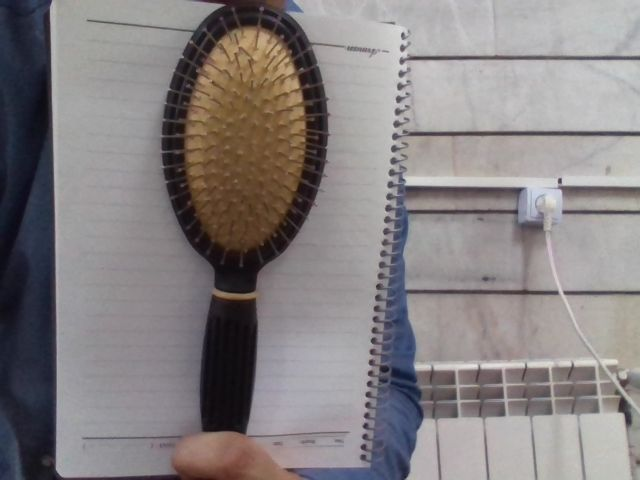

In [ ]:
img = cv2.imread('photo.jpg', cv2.IMREAD_UNCHANGED)
cv2_imshow(img)

In [ ]:
img = cv2.resize(img, (224, 224))
img = np.expand_dims(img, axis=0)

In [ ]:
v2_img = keras.applications.mobilenet_v2.preprocess_input(img)
pred = MNv2.predict(v2_img)
keras.applications.mobilenet_v2.decode_predictions(pred, top=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


[[('n02865351', 'bolo_tie', 0.6309137),
  ('n03720891', 'maraca', 0.01612151),
  ('n02906734', 'broom', 0.013988984),
  ('n02787622', 'banjo', 0.011215531),
  ('n03532672', 'hook', 0.010242301)]]

In [ ]:
v3_small_img = keras.applications.mobilenet_v3.preprocess_input(img)
pred = MNv3Small.predict(v3_small_img)
keras.applications.mobilenet_v3.decode_predictions(pred, top=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


[[('n03271574', 'electric_fan', 0.123489976),
  ('n04039381', 'racket', 0.06778389),
  ('n03970156', 'plunger', 0.050646942),
  ('n03483316', 'hand_blower', 0.042132374),
  ('n04447861', 'toilet_seat', 0.04106808)]]

In [ ]:
v3_large_img = keras.applications.mobilenet_v3.preprocess_input(img)
pred = MNv3Large.predict(v3_large_img)
keras.applications.mobilenet_v3.decode_predictions(pred, top=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


[[('n02787622', 'banjo', 0.24793139),
  ('n03272010', 'electric_guitar', 0.09264188),
  ('n02676566', 'acoustic_guitar', 0.044578265),
  ('n02865351', 'bolo_tie', 0.029212886),
  ('n03495258', 'harp', 0.0288818)]]